In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph, START, END

In [ ]:
class AgentState(TypedDict):
    number1: int
    number2: int
    operation1: str
    number3: int
    number4: int
    operation2: str
    final1: int
    final2: int

In [17]:
def add_node1(state: AgentState) -> AgentState:
    state['final1'] = state['number1'] + state['number2']
    return state

def add_node2(state: AgentState) -> AgentState:
    state['final2'] = state['number3'] + state['number4']
    return state

def sub_node1(state: AgentState) -> AgentState:
    state['final1'] = state['number1'] - state['number2']
    return state

def sub_node2(state: AgentState) -> AgentState:
    state['final2'] = state['number3'] - state['number4']
    return state

def router1(state: AgentState) -> AgentState:
    if state["operation1"] == "+":
        return "addition_operator1"
    else:
        return "subtraction_operation1"

def router2(state: AgentState) -> AgentState:
    if state["operation2"] == "+":
        return "addition_operator2"
    else:
        return "subtraction_operation2"


In [22]:
graph = StateGraph(AgentState)
graph.add_node("add_node1", add_node1)
graph.add_node("add_node2", add_node2)

graph.add_node("router1", lambda state: state)

graph.add_node("sub_node1", sub_node1)
graph.add_node("sub_node2", sub_node2)

graph.add_node("router2", lambda state: state)

graph.add_edge(START, "router1")
graph.add_conditional_edges(
    "router1",
    router1,
    {
        "addition_operator1": "add_node1",
        "subtraction_operation1": "sub_node1"
    }
)

graph.add_edge("add_node1", "router2")
graph.add_edge("sub_node1", "router2")

graph.add_conditional_edges(
    "router2",
    router2,
    {
        "addition_operator2": "add_node2",
        "subtraction_operation2": "sub_node2"

    }
)

graph.add_edge("add_node2", END)
graph.add_edge("sub_node2", END)

app = graph.compile()


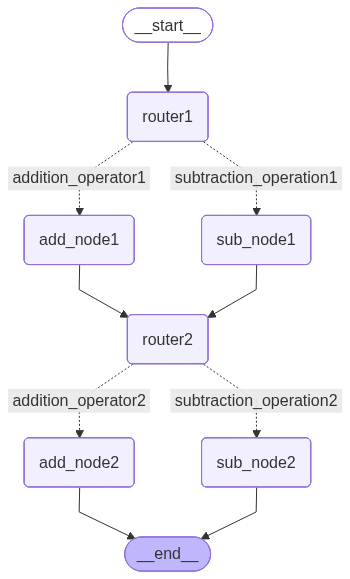

In [23]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [26]:
message = app.invoke({
    "number1": 5,
    "number2": 5,
    "operation1": "+",
    "number3": 4,
    "number4": 2,
    "operation2": "-"
})
print(message['final1'])
print(message['final2'])

10
2
